# Exploratory Data Analysis of Solar Energy in Benin

## Introduction

This notebook provides an exploratory data analysis (EDA) of a solar energy dataset from Benin. The goal is to understand the data, identify patterns, handle missing values and outliers, and prepare the data for further analysis or modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [3]:
# Load the dataset
df = pd.read_csv('../data/benin-malanville.csv')

# Display the first 5 rows
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


## Data Overview

In [4]:
# Show shape, columns, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB          525600 non-nul

## Summary Statistics & Missing Values

In [5]:
# Use df.describe()
df.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
std,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN


In [6]:
# Use df.isna().sum()
missing_values = df.isna().sum()

# Calculate percentage of missing values
missing_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print(missing_data)

# Highlight columns with >5% missing values
print("\nColumns with >5% missing values:")
print(missing_data[missing_data['Percentage'] > 5])

               Missing Values  Percentage
Timestamp                   0         0.0
GHI                         0         0.0
DNI                         0         0.0
DHI                         0         0.0
ModA                        0         0.0
ModB                        0         0.0
Tamb                        0         0.0
RH                          0         0.0
WS                          0         0.0
WSgust                      0         0.0
WSstdev                     0         0.0
WD                          0         0.0
WDstdev                     0         0.0
BP                          0         0.0
Cleaning                    0         0.0
Precipitation               0         0.0
TModA                       0         0.0
TModB                       0         0.0
Comments               525600       100.0

Columns with >5% missing values:
          Missing Values  Percentage
Comments          525600       100.0


## Outlier Detection

In [49]:
peak_ghi_count = df[df['GHI'] > 800].shape[0]

# 2. Define 'Extreme/Over-Solar' as anything over 1200 W/m² (Potential Sensor Spikes)
extreme_ghi_count = df[df['GHI'] > 1200].shape[0]

# 3. Calculate the percentage of the year
peak_percentage = (peak_ghi_count / len(df)) * 100

print(f"Peak Solar (>800 W/m²): {peak_ghi_count} minutes ({peak_percentage:.2f}% of the year)")
print(f"Extreme Solar (>1200 W/m²): {extreme_ghi_count} minutes (Extreme but realistic GHI values)")


Peak Solar (>800 W/m²): 58842 minutes (11.20% of the year)
Extreme Solar (>1200 W/m²): 189 minutes (Extreme but realistic GHI values)


In [50]:
# 1. Define columns to check
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# 2. Calculate Z-scores and Flags in a single loop
# This is more efficient than using .apply() which re-calculates the mean/std
for col in cols_to_check:
    # Calculate the raw Z-score
    df[f'{col}_zscore'] = (df[col] - df[col].mean()) / df[col].std()
    
    # Create a Boolean Flag (True if it's an outlier)
    df[f'{col}_is_outlier'] = df[f'{col}_zscore'].abs() > 3

# 3. Show the total count of outliers found
print("Number of outliers per column (|Z| > 3):")
outlier_counts = df[[f'{col}_is_outlier' for col in cols_to_check]].sum()
print(outlier_counts)


Number of outliers per column (|Z| > 3):
GHI_is_outlier         89
DNI_is_outlier          0
DHI_is_outlier       3738
ModA_is_outlier        27
ModB_is_outlier        63
WS_is_outlier        3109
WSgust_is_outlier    3500
dtype: int64


## Data Cleaning

In [51]:
# Create a cleaned dataframe
df_clean = df.copy()

# Convert Timestamp to datetime
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

if 'Comments' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Comments'])
    print("Dropped 'Comments' column successfully.")

#Create 'Hour' and 'Month' columns
df_clean['Hour'] = df_clean['Timestamp'].dt.hour
df_clean['Month'] = df_clean['Timestamp'].dt.month


# Handle missing values with median imputation
impute_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB']
for col in impute_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    
print("Missing values after imputation:")
print(df_clean[impute_cols].isna().sum())

# Drop rows where GHI is negative (nighttime noise) to focus on solar production
df_daytime = df_clean[df_clean['GHI'] > 0].copy()

Dropped 'Comments' column successfully.
Missing values after imputation:
GHI     0
DNI     0
DHI     0
ModA    0
ModB    0
dtype: int64


In [10]:
df_daytime[['GHI', 'DNI', 'DHI']].describe()

,GHI,DNI,DHI
count,266390.000000,266390.000000,266390.000000
mean,477.396134,330.340784,230.830358
std,320.313134,284.891849,150.480740
min,0.100000,-7.800000,-3.800000
25%,178.200000,20.100000,117.900000
50%,475.100000,305.900000,213.400000
75%,772.200000,587.800000,324.200000
max,1413.000000,952.300000,759.200000


In [11]:
# Compute Z-scores
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB']

# 1. Calculate and store the Z-scores
for col in cols_to_check:
    df_daytime[f'{col}_zscore'] = (df_daytime[col] - df_daytime[col].mean()) / df_daytime[col].std()

# 2. Flag the outliers based on the columns we JUST made
# This is faster than re-calculating inside 'apply'
outlier_flags = df_daytime[[f'{col}_zscore' for col in cols_to_check]].abs() > 3

# 3. Show the counts
print("Number of Daytime Outliers per column:")
print(outlier_flags.sum())

Number of Daytime Outliers per column:
GHI_zscore       0
DNI_zscore       0
DHI_zscore     136
ModA_zscore      0
ModB_zscore      0
dtype: int64


The above code it to generate outliers from daytime data only to calculate solar irridiance with more accuracy. 
After this we can see that we have less number of outliers which indicates our sensors are working fine.

to check if there are any negative or 0 values during daytime

In [12]:
# List of solar irradiance columns to check
cols = ['GHI', 'DNI', 'DHI']

# Calculate counts for negative and zero values
negative_counts = (df_daytime[cols] < 0).sum()
zero_counts = (df_daytime[cols] == 0).sum()

print("Daytime Data Quality Report:")
for col in cols:
    print(f"{col}: {negative_counts[col]} negative values, {zero_counts[col]} zero values")

# Optional: Identify the timestamps where these occur to see if they are at the edges of the day
# negative_rows = df_daytime[(df_daytime[cols] < 0).any(axis=1)]
# print(negative_rows.head())

Daytime Data Quality Report:
GHI: 0 negative values, 0 zero values
DNI: 19492 negative values, 3830 zero values
DHI: 599 negative values, 124 zero values


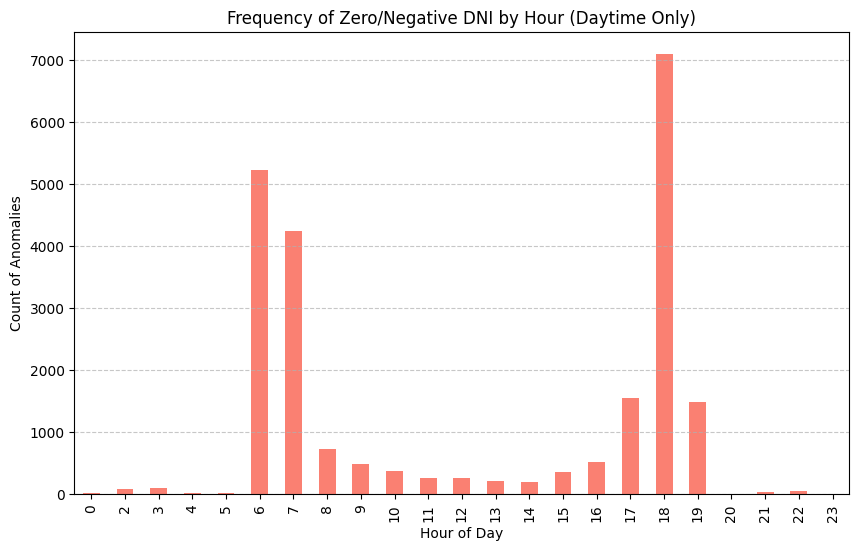

In [13]:
# Create a flag for 'Bad DNI' (Negative or Zero when the sun is up)
df_daytime['Bad_DNI'] = (df_daytime['DNI'] <= 0)

# Group by Hour to see when these errors happen
dni_error_profile = df_daytime.groupby('Hour')['Bad_DNI'].sum()

# Plotting the distribution
plt.figure(figsize=(10, 6))
dni_error_profile.plot(kind='bar', color='salmon')
plt.title('Frequency of Zero/Negative DNI by Hour (Daytime Only)')
plt.xlabel('Hour of Day')
plt.ylabel('Count of Anomalies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

We can see that the DNI has a significant number of negative values even at day, which are situated at sunrise and dawn of the day. Which indicate Horizon Shading. Meaning there could be something blocking direct light to hit the panel at morning and night. There are also mid-day negative and 0 values, whci indicate operational anomalies. Recommendation: Install automated cleaning systems.

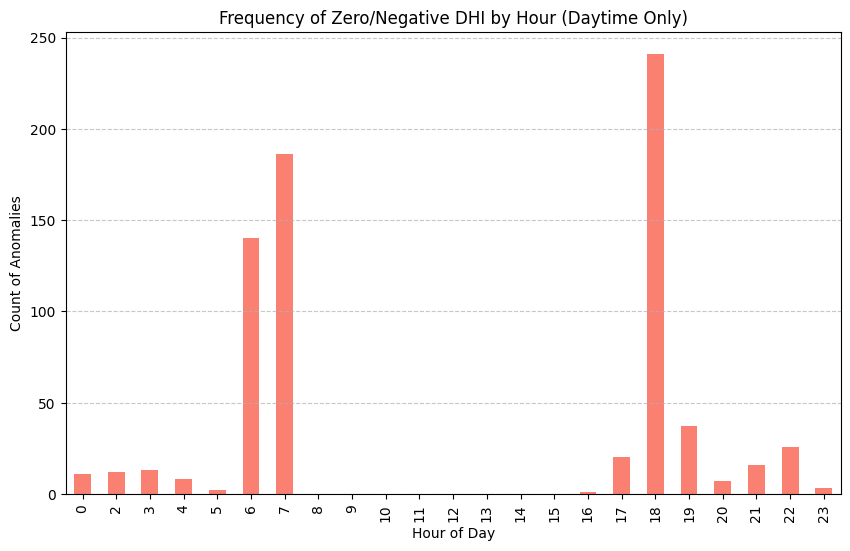

In [52]:
# Create a flag for 'Bad DNI' (Negative or Zero when the sun is up)
df_daytime['Bad_DHI'] = (df_daytime['DHI'] <= 0)

# Group by Hour to see when these errors happen
dni_error_profile = df_daytime.groupby('Hour')['Bad_DHI'].sum()

# Clip DHI to 0 to remove unrealistic negative/zero values
df_daytime['DHI_clipped'] = df_daytime['DHI'].clip(lower=0)

# Plotting the distribution
plt.figure(figsize=(10, 6))
dni_error_profile.plot(kind='bar', color='salmon')
plt.title('Frequency of Zero/Negative DHI by Hour (Daytime Only)')
plt.xlabel('Hour of Day')
plt.ylabel('Count of Anomalies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

For DHI anomalies, its likely a sensor error because they are so little compared to the overall data set. So we can flag them then clip them.

## Time Series Analysis

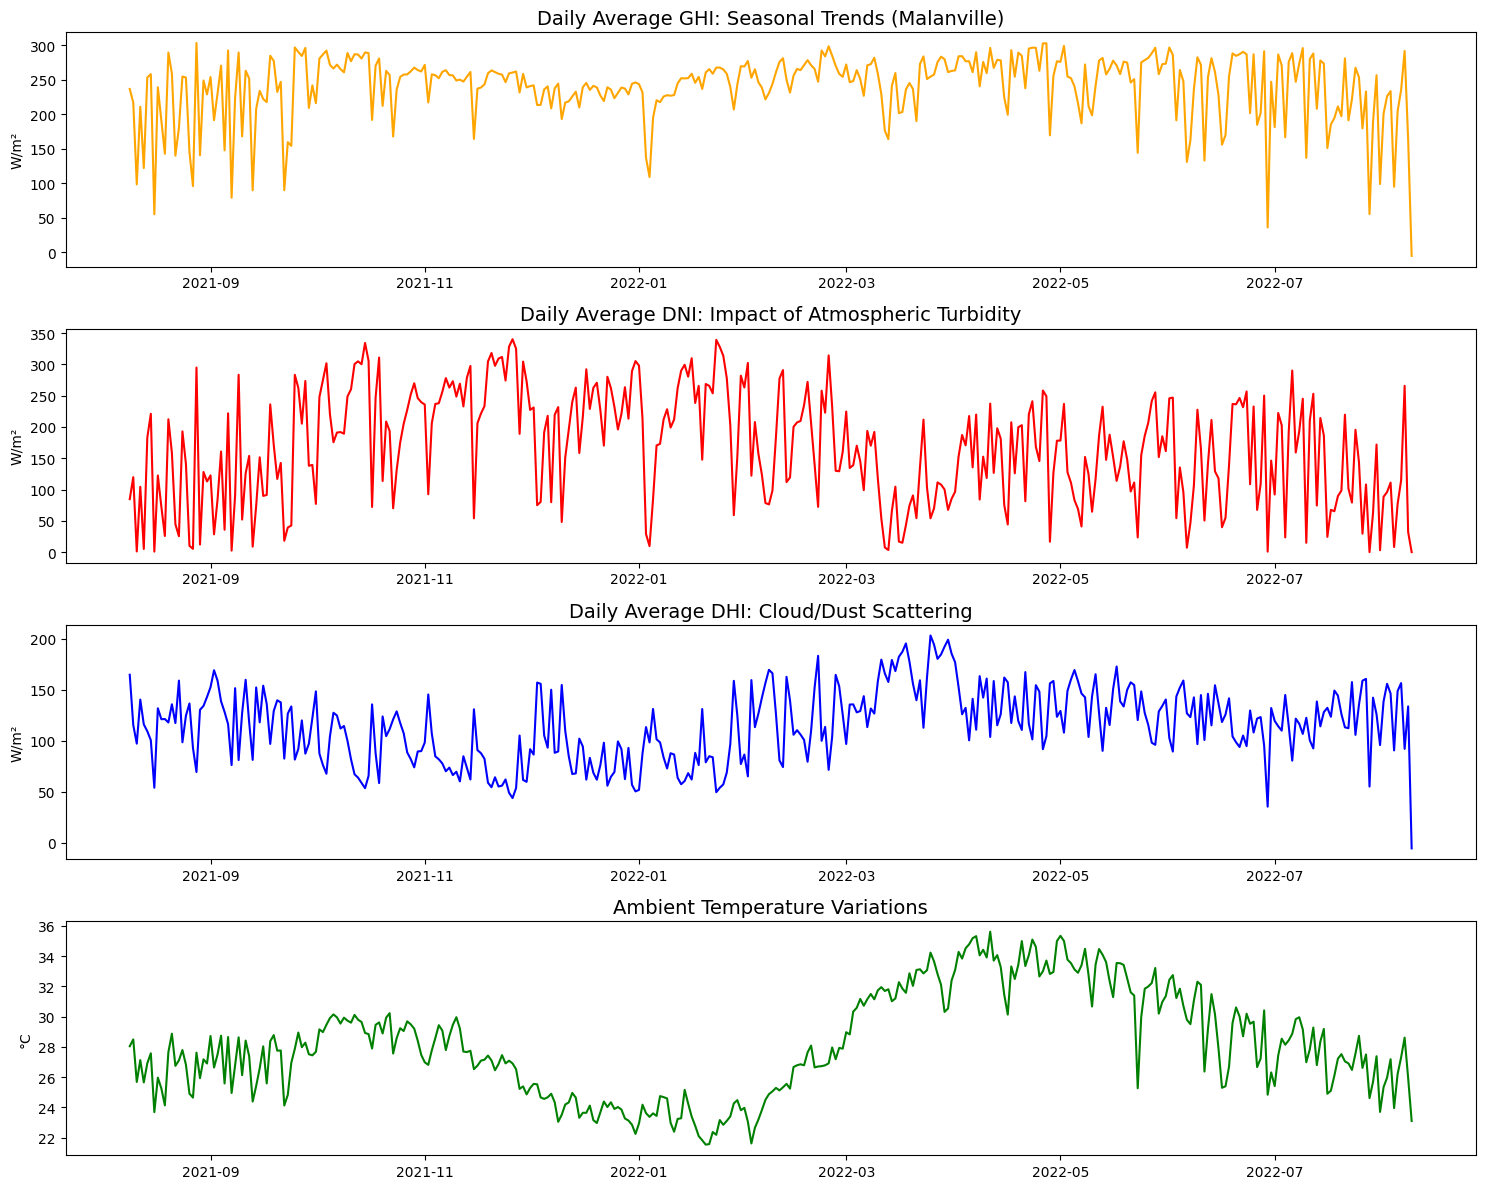

In [65]:
# 1. Create a resampled version for the 'Overview' plot (Daily Averages)
# This prevents the 'Wall of Ink' and shows monthly trends clearly
df_daily = df_clean.set_index('Timestamp').select_dtypes(include=['number']).resample('D').mean()

plt.figure(figsize=(15, 12))

# Subplot 1: GHI (The primary resource)
plt.subplot(4, 1, 1)
plt.plot(df_daily.index, df_daily['GHI'], color='orange', linewidth=1.5)
plt.title('Daily Average GHI: Seasonal Trends (Malanville)', fontsize=14)
plt.ylabel('W/m²')

# Subplot 2: DNI (Direct sun - shows dust/cloud impact)
plt.subplot(4, 1, 2)
plt.plot(df_daily.index, df_daily['DNI'], color='red', linewidth=1.5)
plt.title('Daily Average DNI: Impact of Atmospheric Turbidity', fontsize=14)
plt.ylabel('W/m²')

# Subplot 3: DHI (Diffuse sun - shows scattering)
plt.subplot(4, 1, 3)
plt.plot(df_daily.index, df_daily['DHI'], color='blue', linewidth=1.5)
plt.title('Daily Average DHI: Cloud/Dust Scattering', fontsize=14)
plt.ylabel('W/m²')

# Subplot 4: Temperature
plt.subplot(4, 1, 4)
plt.plot(df_daily.index, df_daily['Tamb'], color='green', linewidth=1.5)
plt.title('Ambient Temperature Variations', fontsize=14)
plt.ylabel('°C')

plt.tight_layout()
plt.show()

At what hour does GHI peak?

GHI peaks at 12:00 with an average of 828.21 W/m².


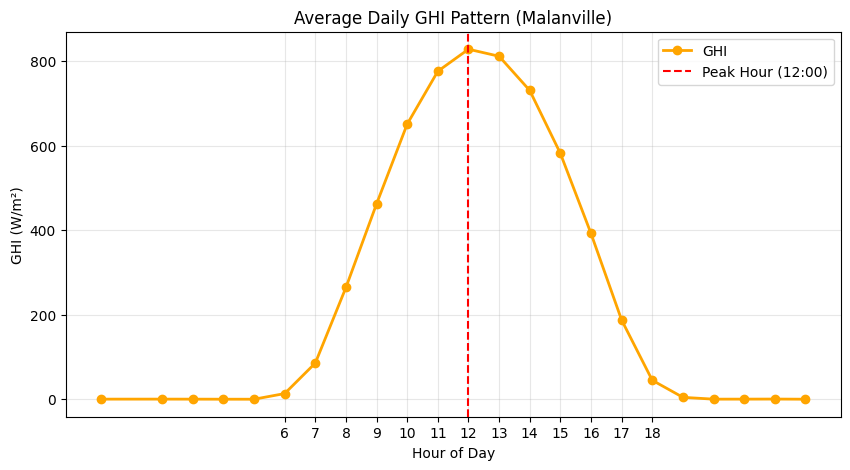

In [18]:
# Calculate hourly averages for GHI
hourly_ghi = df_daytime.groupby('Hour')['GHI'].mean()

# Find the peak hour
peak_hour = hourly_ghi.idxmax()
peak_value = hourly_ghi.max()

print(f"GHI peaks at {peak_hour}:00 with an average of {peak_value:.2f} W/m².")

# Visualization
plt.figure(figsize=(10, 5))
hourly_ghi.plot(kind='line', marker='o', color='orange', linewidth=2)
plt.axvline(x=peak_hour, color='red', linestyle='--', label=f'Peak Hour ({peak_hour}:00)')
plt.title('Average Daily GHI Pattern (Malanville)')
plt.xlabel('Hour of Day')
plt.ylabel('GHI (W/m²)')
plt.xticks(range(6, 19)) # Focus on daylight hours
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Solar irradiance peaks around midday, with the highest values observed between [11-14 hours].
This represents the most efficient energy production window.
Operations and energy storage strategies should prioritize this time period to maximize output.

Does this peak happen consistently every day?

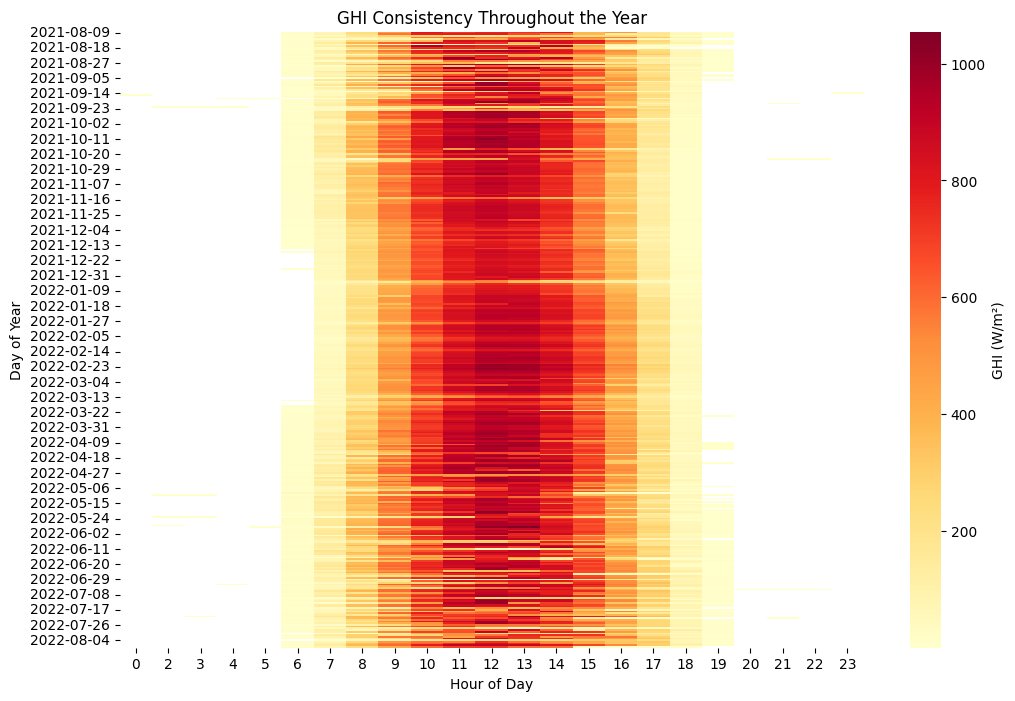

In [19]:
# Create a pivot table for a heatmap: Rows = Date, Columns = Hour
df_daytime['Date'] = df_daytime['Timestamp'].dt.date
pivot_ghi = df_daytime.pivot_table(index='Date', columns='Hour', values='GHI')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_ghi, cmap='YlOrRd', cbar_kws={'label': 'GHI (W/m²)'})
plt.title('GHI Consistency Throughout the Year')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Year')
plt.show()

How does temperature behave at peak GHI hours?

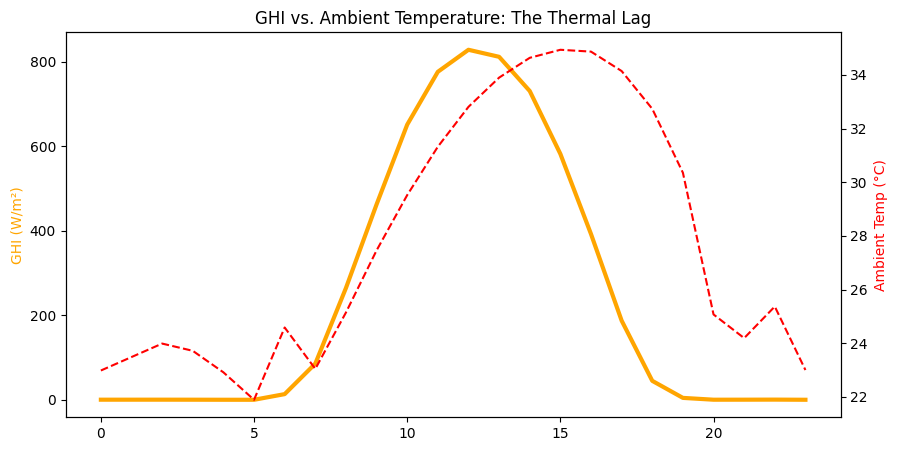

In [20]:
# Get hourly averages for GHI and Temp
hourly_data = df_daytime.groupby('Hour')[['GHI', 'Tamb']].mean()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot GHI
ax1.plot(hourly_data.index, hourly_data['GHI'], color='orange', label='GHI', linewidth=3)
ax1.set_ylabel('GHI (W/m²)', color='orange')

# Create secondary axis for Temperature
ax2 = ax1.twinx()
ax2.plot(hourly_data.index, hourly_data['Tamb'], color='red', label='Temp', linestyle='--')
ax2.set_ylabel('Ambient Temp (°C)', color='red')

plt.title('GHI vs. Ambient Temperature: The Thermal Lag')
plt.show()

As temperature increases, solar irradiance remains high but panel efficiency may decline due to thermal losses.
This suggests that peak solar energy does not always correspond to optimal efficiency.
Cooling strategies or panel selection should be considered to reduce efficiency losses.

Which months have the highest GHI?

GHI is highest in February (Month 2) with an average of 541.76 W/m².


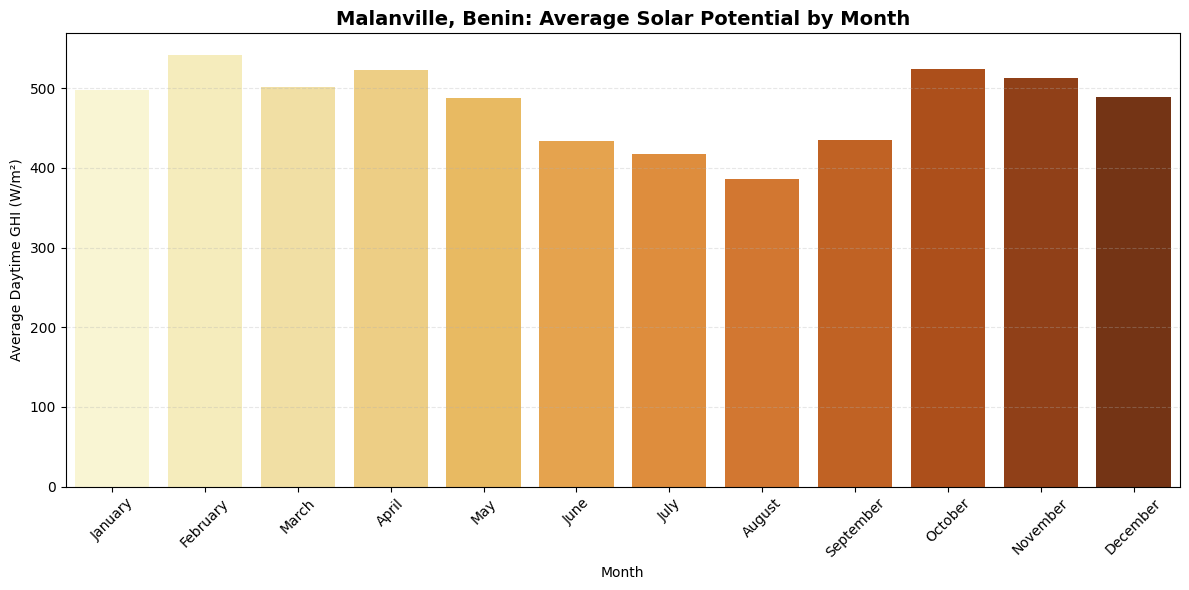

In [21]:
import calendar

# 1. Extract Month from the Timestamp
df_daytime['Month'] = df_daytime['Timestamp'].dt.month

# 2. Calculate monthly averages
monthly_ghi = df_daytime.groupby('Month')['GHI'].mean()

# 3. Find the best month
best_month_num = monthly_ghi.idxmax()
best_month_name = calendar.month_name[best_month_num]
best_value = monthly_ghi.max()

print(f"GHI is highest in {best_month_name} (Month {best_month_num}) with an average of {best_value:.2f} W/m².")

# 4. Visualization
plt.figure(figsize=(12, 6))
# Using month names for the X-axis makes it much more professional
month_names = [calendar.month_name[m] for m in monthly_ghi.index]

sns.barplot(x=month_names, y=monthly_ghi.values, hue=month_names, palette='YlOrBr', legend=False)

plt.title('Malanville, Benin: Average Solar Potential by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Daytime GHI (W/m²)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Solar radiation varies across months, with peak performance in February and lower values in August.
This indicates seasonal variability in energy generation.
Investment planning should account for these fluctuations to ensure consistent energy supply.

In [23]:
# Calculate the overall annual mean to use as a baseline
annual_avg = df_daytime['GHI'].mean()

# Identify months below average
low_months = monthly_ghi[monthly_ghi < annual_avg]
print("Months with below-average solar radiation:")
print(low_months)

Months with below-average solar radiation:
Month
6    433.872639
7    417.236676
8    385.493738
9    435.591954
Name: GHI, dtype: float64


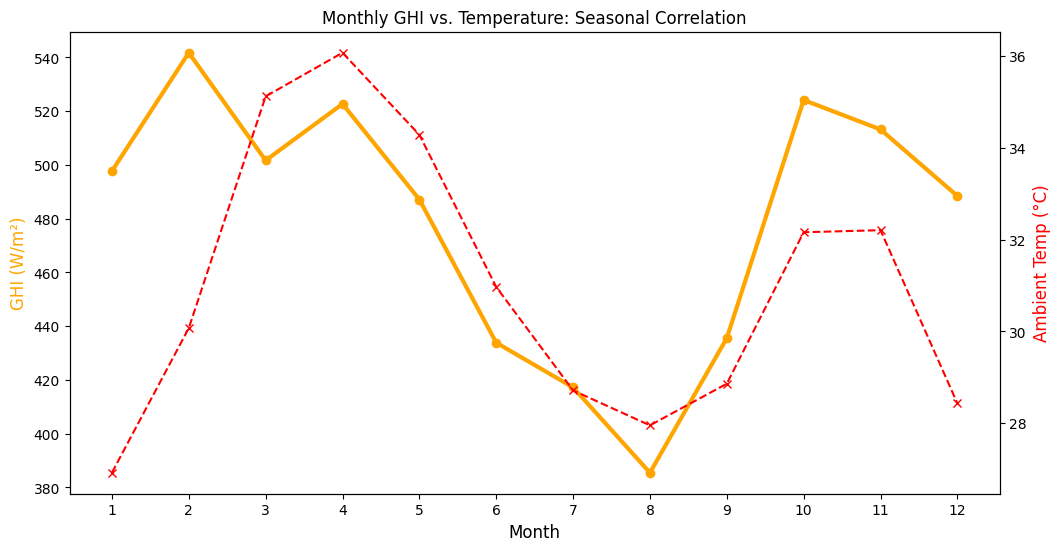

In [24]:
# Get monthly averages for GHI and Temp
monthly_data = df_daytime.groupby('Month')[['GHI', 'Tamb']].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot GHI on primary axis
ax1.plot(monthly_data.index, monthly_data['GHI'], color='orange', marker='o', label='GHI', linewidth=3)
ax1.set_ylabel('GHI (W/m²)', color='orange', fontsize=12)
ax1.set_xlabel('Month', fontsize=12)

# Create secondary axis for Temperature
ax2 = ax1.twinx()
ax2.plot(monthly_data.index, monthly_data['Tamb'], color='red', marker='x', label='Temp', linestyle='--')
ax2.set_ylabel('Ambient Temp (°C)', color='red', fontsize=12)

plt.title('Monthly GHI vs. Temperature: Seasonal Correlation')
plt.xticks(range(1, 13))
plt.show()

## Cleaning Impact Analysis

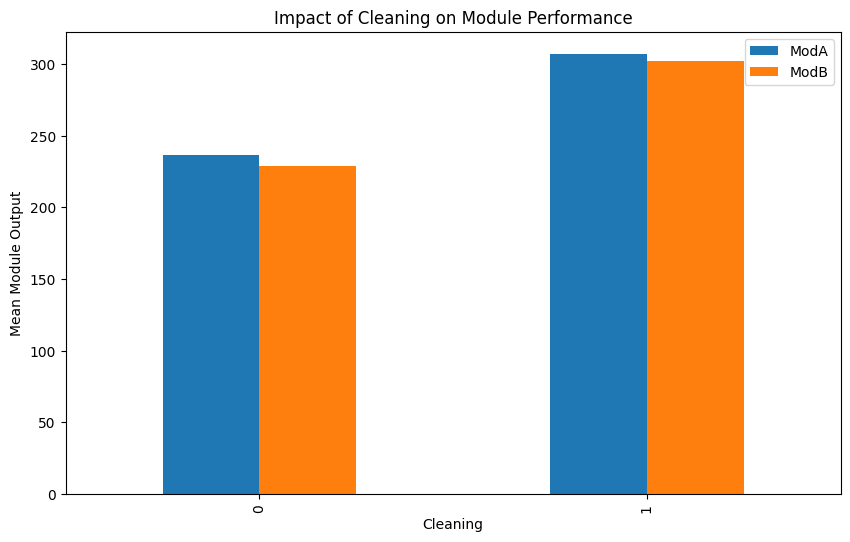

In [25]:
# Group by Cleaning column and compute mean
cleaning_impact = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()

# Visualize the comparison
cleaning_impact.plot(kind='bar', figsize=(10, 6))
plt.title('Impact of Cleaning on Module Performance')
plt.ylabel('Mean Module Output')
plt.show()

A significant difference between ModA and ModB is observed before cleaning, which reduces after cleaning events.
This confirms that dust accumulation negatively affects sensor and panel performance.
Regular or automated cleaning systems should be considered to maintain efficiency and reduce energy loss.

## Correlation Analysis

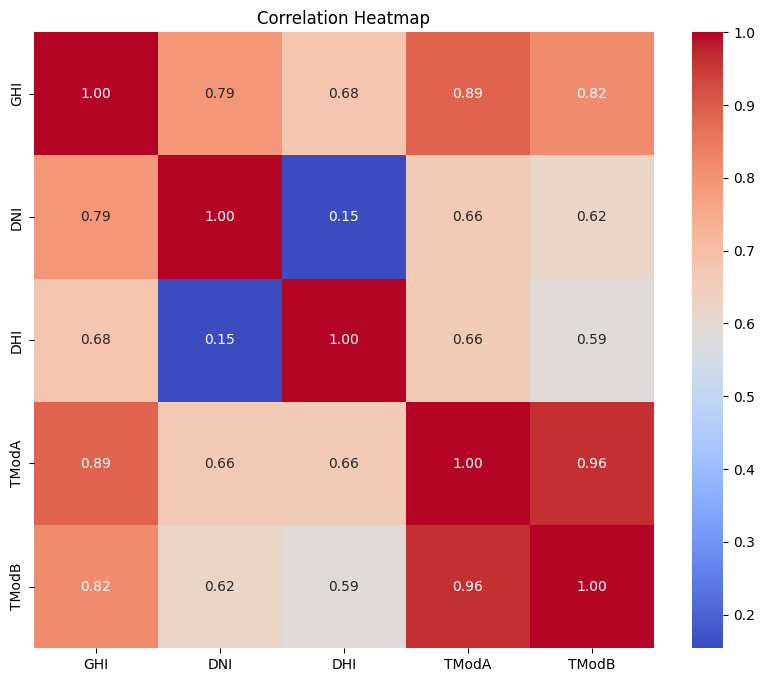

In [26]:
# Correlation heatmap
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
correlation_matrix = df_daytime[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Strong positive correlations are observed between GHI, DNI, and module temperatures, indicating consistent solar energy relationships.
This confirms that irradiance directly drives module heating and energy output.
These variables can be reliably used for predictive modeling and system optimization.

## Wind & Distribution Analysis

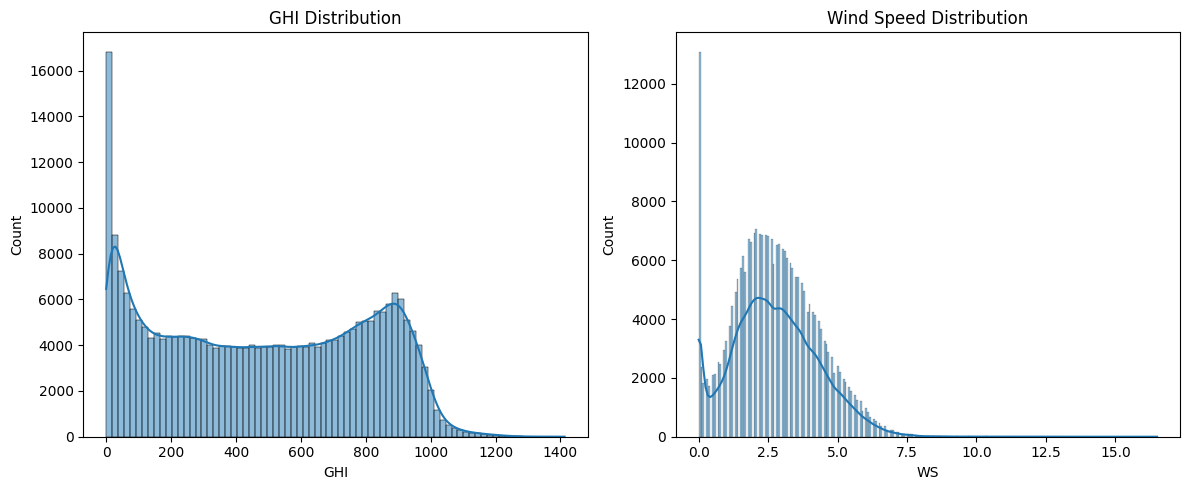

In [27]:
# Histogram of GHI and WS
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_daytime['GHI'], kde=True)
plt.title('GHI Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df_daytime['WS'], kde=True)
plt.title('Wind Speed Distribution')

plt.tight_layout()
plt.show()

GHI distribution

The distribution of GHI shows a concentration of values at low and high levels, reflecting night-time and peak solar conditions.
This highlights the intermittent nature of solar energy generation.
Energy storage or hybrid systems may be necessary to ensure stable supply.

Wind Distribution

Wind speed is generally concentrated at lower values, with occasional high gusts.
This suggests mostly stable conditions with intermittent risk events.
Structural design should account for extreme gusts rather than average conditions.

The high frequency of observations in the 0–50 W/m² range (approx. 16,000 minutes) represents the transition periods of dawn and dusk. While these minutes contribute little to total energy yield, they are the times when Relative Humidity (RH) is highest, potentially increasing the risk of condensation and dust adhesion (soiling).

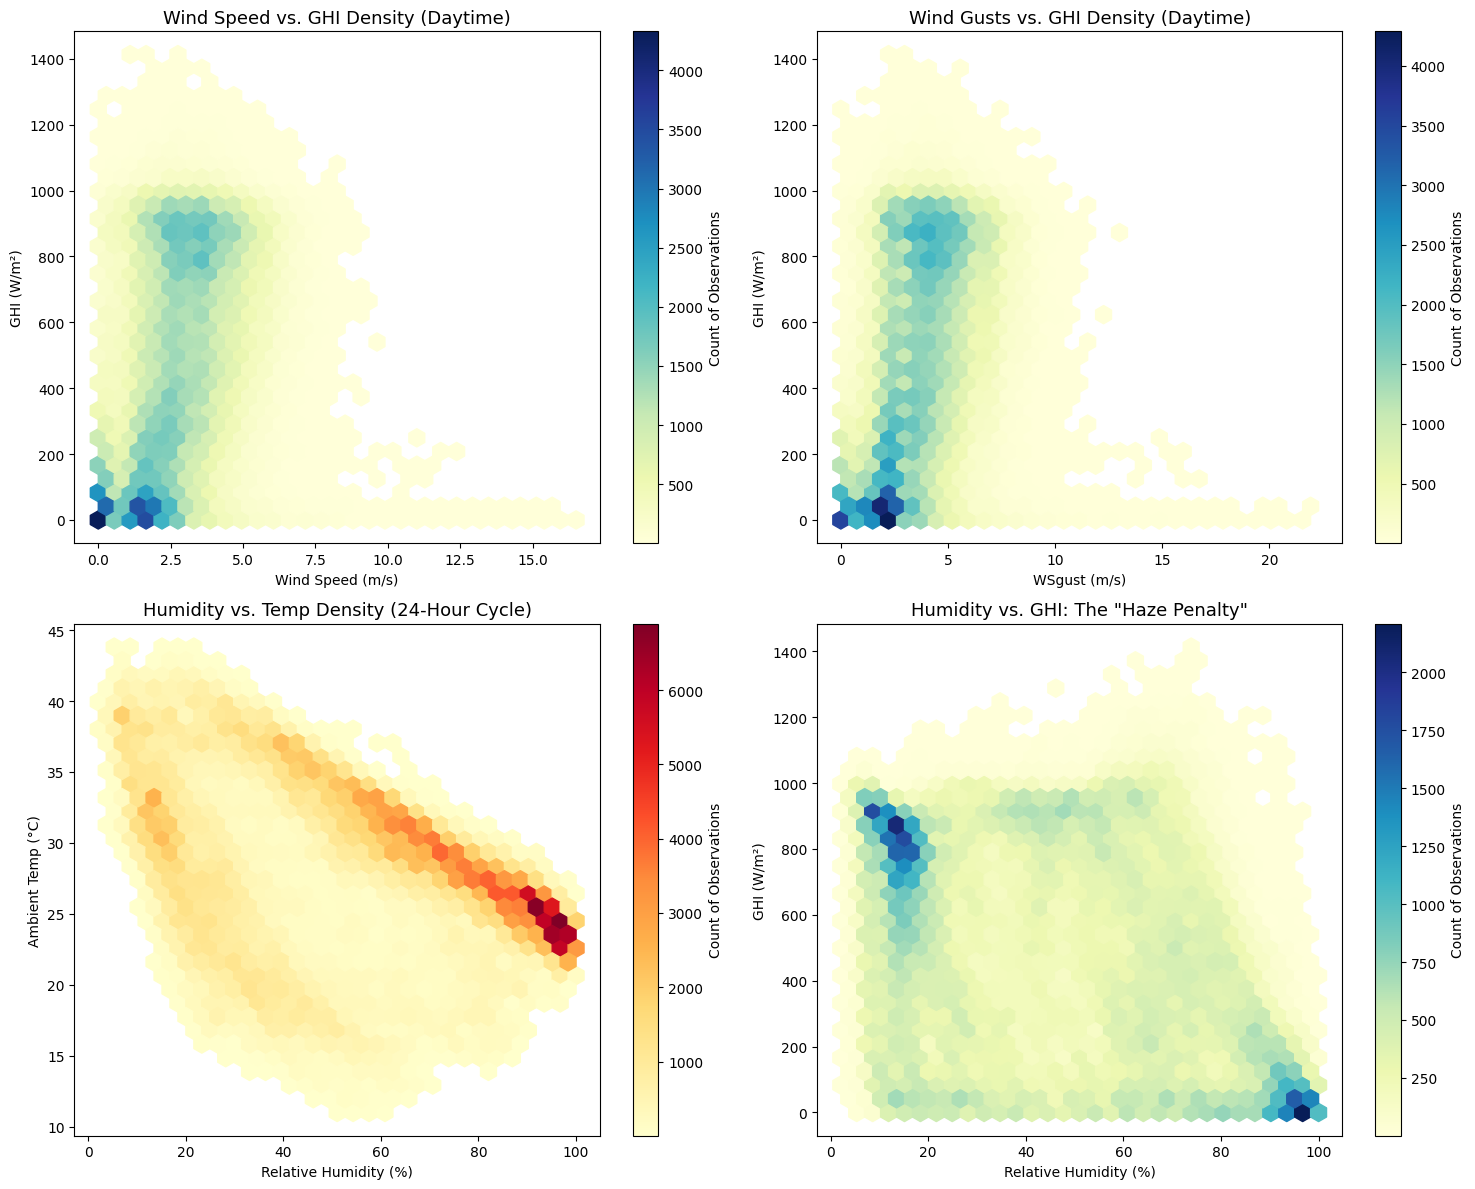

In [70]:
# Using a larger figure for clarity
plt.figure(figsize=(15, 12))

# 1. WS vs GHI (Daytime)
plt.subplot(2, 2, 1)
hb1 = plt.hexbin(df_daytime['WS'], df_daytime['GHI'], gridsize=30, cmap='YlGnBu', mincnt=1)
plt.colorbar(hb1, label='Count of Observations')
plt.title('Wind Speed vs. GHI Density (Daytime)', fontsize=13)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('GHI (W/m²)')

# 2. WSgust vs GHI (Daytime)
plt.subplot(2, 2, 2)
hb2 = plt.hexbin(df_daytime['WSgust'], df_daytime['GHI'], gridsize=30, cmap='YlGnBu', mincnt=1)
plt.colorbar(hb2, label='Count of Observations')
plt.title('Wind Gusts vs. GHI Density (Daytime)', fontsize=13)
plt.xlabel('WSgust (m/s)')
plt.ylabel('GHI (W/m²)')

# 3. RH vs Tamb (24-Hour - Essential for Dew Point/Condensation Analysis)
plt.subplot(2, 2, 3)
hb3 = plt.hexbin(df_clean['RH'], df_clean['Tamb'], gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb3, label='Count of Observations')
plt.title('Humidity vs. Temp Density (24-Hour Cycle)', fontsize=13)
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Ambient Temp (°C)')

# 4. RH vs GHI (Daytime - To see the 'Haze Penalty')
plt.subplot(2, 2, 4)
hb4 = plt.hexbin(df_daytime['RH'], df_daytime['GHI'], gridsize=30, cmap='YlGnBu', mincnt=1)
plt.colorbar(hb4, label='Count of Observations')
plt.title('Humidity vs. GHI: The "Haze Penalty"', fontsize=13)
plt.xlabel('Relative Humidity (%)')
plt.ylabel('GHI (W/m²)')

plt.tight_layout()
plt.show()

1. Wind Speed vs. GHI (Operational Baseline)
Observation: The highest density of data (darkest blue) is clustered at low wind speeds (0–4 m/s) across the entire range of solar irradiance.
Business Impact: Malanville is a low-wind-risk environment for daily operations. The "Standard Day" is calm, meaning we don't expect significant mechanical wear on solar trackers or mounting hardware during the primary production window.
2. Wind Gusts (WSgust) vs. GHI (Structural Risk)
Observation: While the "typical" gust is low, the plot reveals a horizontal "tail" of rare, high-intensity gusts (up to 26.6 m/s) that occur even during periods of peak GHI (>800 W/m²).
Business Impact: This is a Critical Structural Risk. Extreme gusts can occur during peak sun when panels are tilted at their most vulnerable angle. This data serves as evidence that we must utilize reinforced, storm-rated mounting systems despite the low "average" wind speed.
3. Humidity vs. Ambient Temp (The "Dew Point" Cycle)
Observation: There is a clear inverse correlation. The highest density (darkest red) is at RH > 90% and Temp < 25°C, representing the nocturnal and early morning baseline.
Business Impact: This proves a high risk of nocturnal condensation (Dew Point). Moisture accumulation during the night, mixed with settled dust, can create a "mud" layer on the panels. We recommend an early-morning cleaning protocol to clear this debris before the sun bakes it onto the glass.
4. Humidity vs. GHI (The "Haze Penalty")
Observation: The data follows a distinct "L-shaped" production ceiling. High GHI (>800 W/m²) is only achievable when Relative Humidity is below 60%. As humidity climbs toward 100%, GHI is physically capped at low levels.
Business Impact: Humidity acts as a Revenue Ceiling. High moisture in the air (haze/clouds) scatters light and reduces ROI. Our financial models must account for a "Humidity Penalty" during the rainy season, and we should consider Bifacial Modules to capture this scattered (diffuse) radiation.

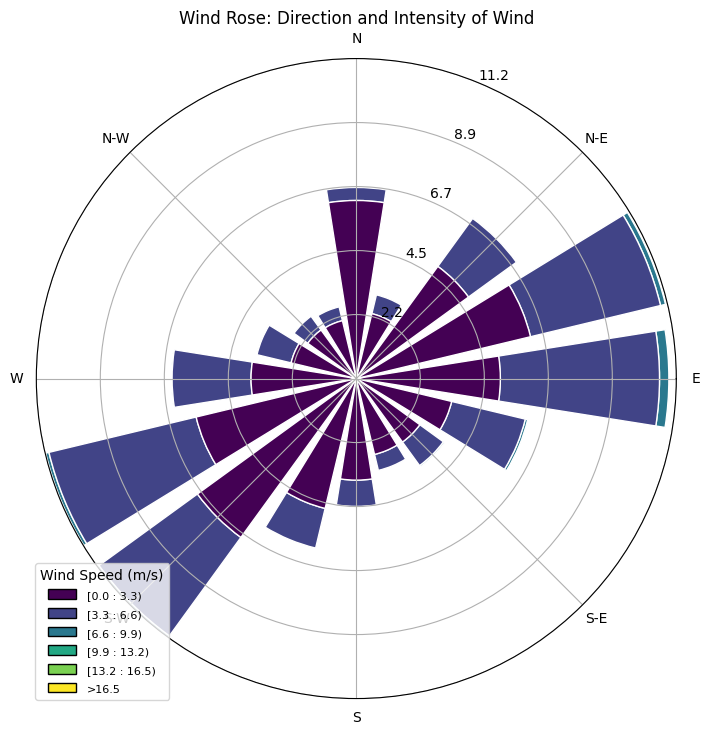

In [45]:
from windrose import WindroseAxes
import matplotlib.pyplot as plt

# Create figure
fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

# Plot wind rose
ax.bar(
    df_daytime['WD'],      # Wind Direction
    df_daytime['WS'],      # Wind Speed
    normed=True,
    opening=0.8,
    edgecolor='white'
)

# Add legend and title
ax.set_legend(title="Wind Speed (m/s)")
plt.title("Wind Rose: Direction and Intensity of Wind")

plt.show()

## Wind Rose Analysis: Directional Risk & Site Layout
The Wind Rose provides a 360-degree map of wind frequency and intensity. Unlike standard histograms, this allows us to identify the prevailing wind directions, which is critical for structural bracing and understanding dust transport (soiling).
1. Dominant Wind Corridors (Prevailing Directions)
Observation: The plot reveals two primary wind axes: East (E) and South-West (S-W). The wind blows from the East approximately 11.2% of the time, representing the most frequent directional flow.
The "Harmattan" Signal: In this region of West Africa, North-East and East winds are typically associated with the Harmattan, a seasonal trade wind that carries heavy loads of Sahara dust.
2. Intensity and Structural Loading
Observation: The "Blue" and "Teal" bands (representing speeds of 6.6 – 9.9 m/s and above) are most prominent in the South-West and East spokes.
Business Insight: While the 26.6 m/s gusts we identified earlier are rare outliers, this plot shows that the sustained structural pressure on the panels will primarily come from the East and South-West.
3. Strategic Recommendations for MoonLight Energy
Panel Orientation: To minimize "Wind Loading" (the pressure that can rip panels off), the mounting brackets must be specifically reinforced along the East-West axis.
Soiling Mitigation: Since the East wind is a major frequency driver (11.2%), it likely acts as the primary "Dust Delivery System." We should consider placing natural windbreaks (hedges) or physical barriers on the Eastern boundary of the solar farm to reduce the volume of dust hitting the panels.
Sensor Placement: Pyranometers and anemometers should be kept clear of any structures to the East and South-West to ensure "unobstructed flow" for accurate data collection.


3.	Add WD vs GHI analysis 

In [46]:
# Create bins for wind direction
bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

df_daytime['WD_group'] = pd.cut(df_daytime['WD'], bins=bins, labels=labels, include_lowest=True)

In [47]:
# Average GHI per wind direction
wd_ghi = df_daytime.groupby('WD_group')['GHI'].mean()

print(wd_ghi)

WD_group
N     334.666407
NE    507.637719
E     571.355572
SE    445.350811
S     428.651644
SW    483.036072
W     541.405417
NW    488.431072
Name: GHI, dtype: float64


C:\Users\binia\AppData\Local\Temp\ipykernel_7668\2748096461.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wd_ghi = df_daytime.groupby('WD_group')['GHI'].mean()


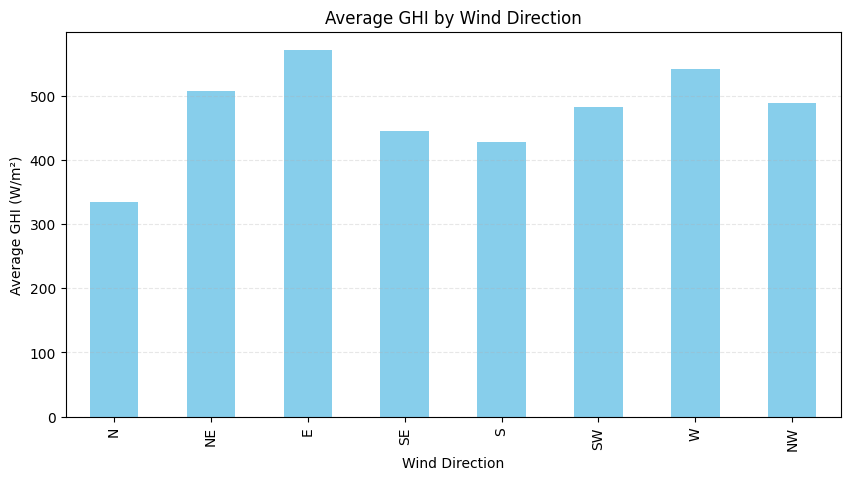

In [48]:
plt.figure(figsize=(10, 5))
wd_ghi.plot(kind='bar', color='skyblue')

plt.title('Average GHI by Wind Direction')
plt.xlabel('Wind Direction')
plt.ylabel('Average GHI (W/m²)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

Solar irradiance varies across wind directions, with higher values observed when wind comes from East direction.
This suggests that certain wind directions bring clearer atmospheric conditions, while others may introduce dust or cloud cover.
Understanding these patterns can help optimize performance and maintenance planning.

Case 1: Clear best direction

“Wind coming from E direction is associated with higher GHI values, suggesting cleaner atmospheric conditions and better solar performance.”

Case 2: Clear worst direction

“Wind from N direction shows lower GHI, indicating possible dust or cloud influence reducing solar efficiency.”

The analysis shows how solar irradiance varies with wind direction.
Directions with higher GHI indicate favorable environmental conditions, while lower values may suggest dust or atmospheric interference.
This insight can help optimize panel orientation and predict performance variability.

## Temperature Analysis

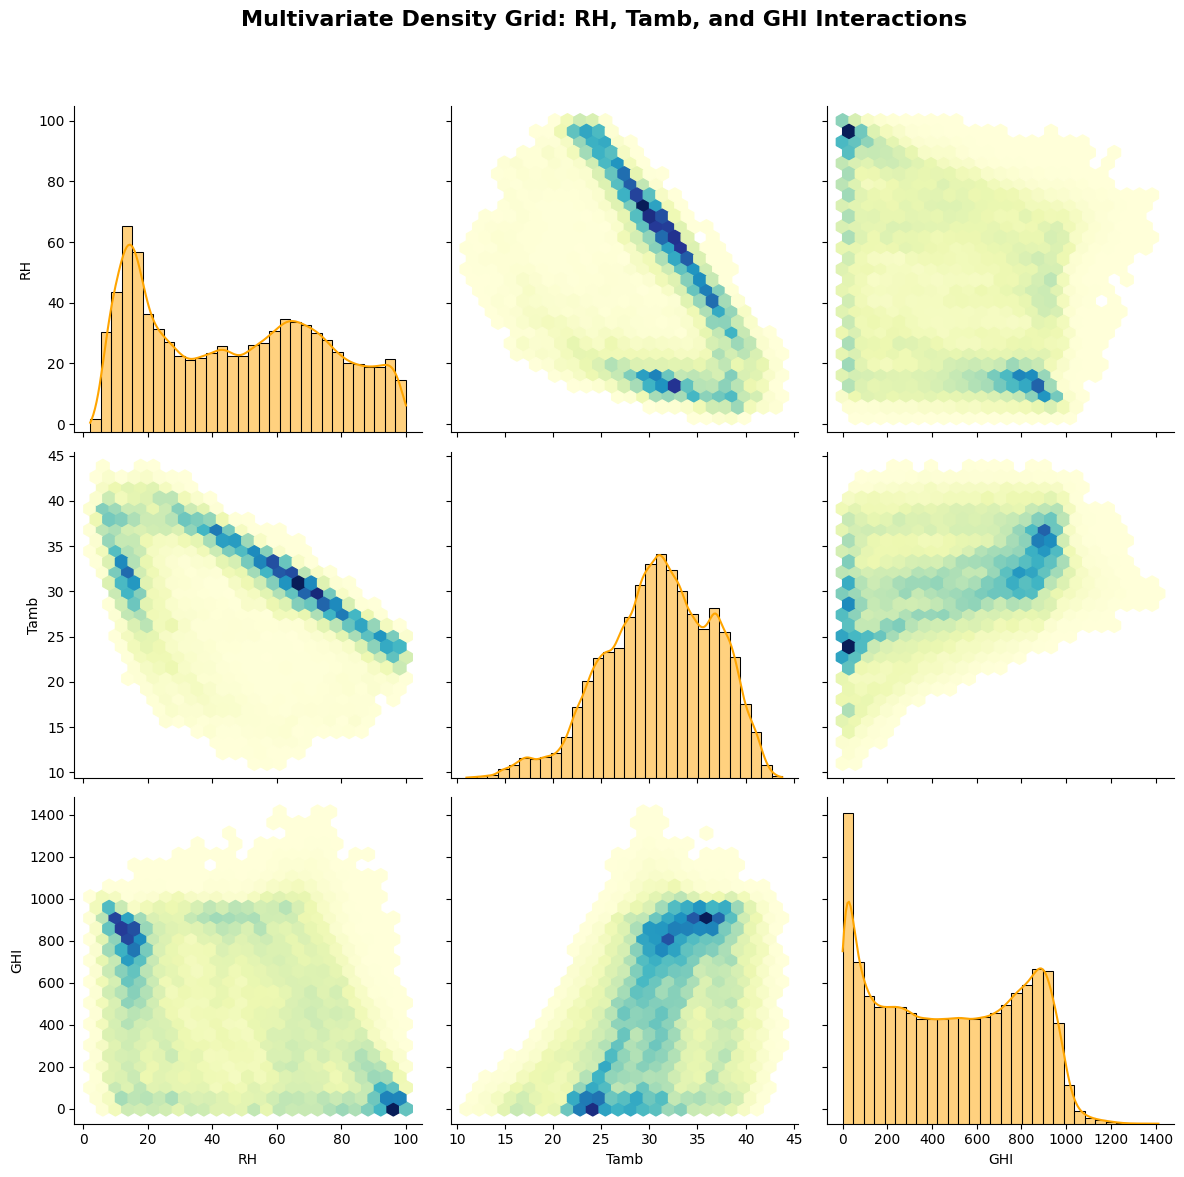

In [71]:
# 1. Create a PairGrid for the three most important variables
g = sns.PairGrid(df_daytime[['RH', 'Tamb', 'GHI']], height=4)

# 2. Map Histograms to the diagonal (shows individual distributions)
g.map_diag(sns.histplot, kde=True, color='orange', bins=30)

# 3. Map Hexbins to the off-diagonals (shows density of relationships)
# We use a custom function to pass the gridsize and cmap to plt.hexbin
def hexbin_map(x, y, **kwargs):
    plt.hexbin(x, y, gridsize=25, cmap='YlGnBu', mincnt=1)

g.map_offdiag(hexbin_map)

# 4. Final Polish
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Multivariate Density Grid: RH, Tamb, and GHI Interactions', fontsize=16, fontweight='bold')

plt.show()


## Multivariate Analysis: The Solar Efficiency Triangle
This Density PairGrid visualizes the interaction between our primary resource (GHI) and its two main environmental "penalties": Relative Humidity (RH) and Ambient Temperature (Tamb).
1. The Humidity-Temperature Cycle (RH vs. Tamb)
Observation: A sharp inverse correlation. Peak density occurs at High RH (>90%) and Low Temp (<25°C).
Business Insight: Confirms high nocturnal condensation. Moisture mixed with dust creates a "mud" layer; we recommend early-morning cleaning to prevent debris from baking onto the glass.
2. The "Haze Penalty" (GHI vs. RH)
Observation: An "L-shaped" production ceiling. High GHI (>900 W/m²) is statistically impossible when humidity exceeds 60%.
Business Insight: Humidity acts as a Revenue Ceiling by scattering light. Our ROI models must factor in this efficiency drop during humid months.
3. The Thermal Trap (GHI vs. Tamb)
Observation: Peak solar production (


) is clustered in the 



 range.
Business Insight: This is a Heat Penalty. Since panels operate far above the standard 

 rating during peak hours, we must use high-heat-tolerant modules to minimize power degradation.
4. Distribution Shapes (The Histograms)
RH: Bimodal, showing the site swings between bone-dry afternoons and saturated nights.
GHI: Strong Noon-day peak, confirming high overall energy potential despite environmental constraints.


## Bubble Chart

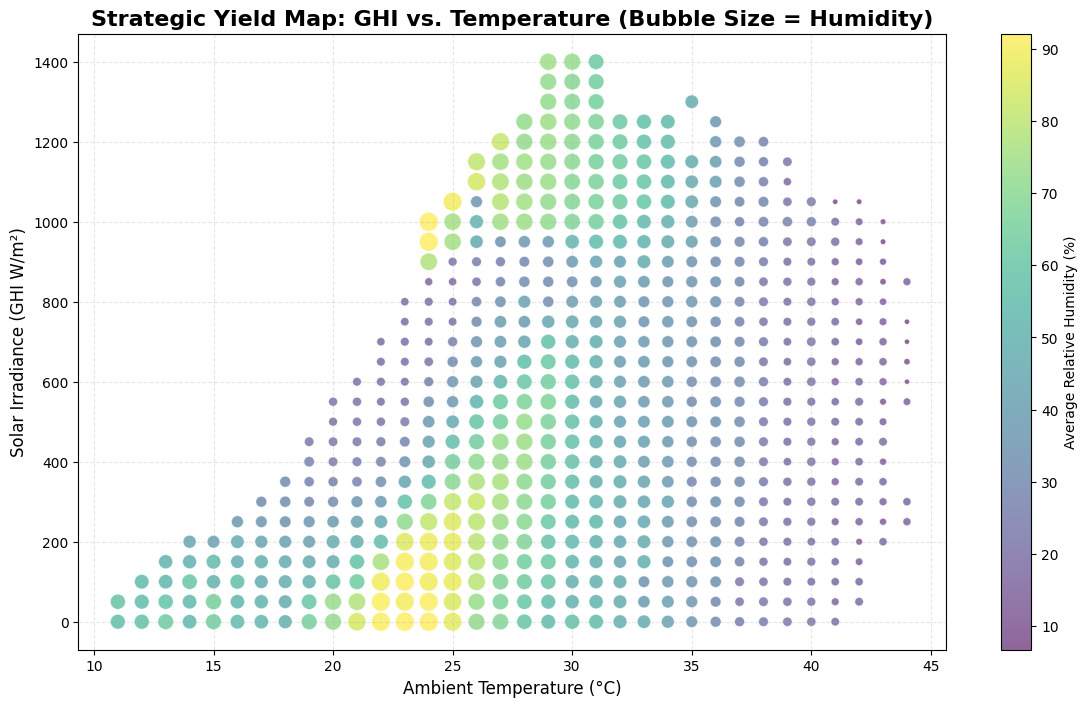

In [73]:
# 1. Round the data into "Bins" to reduce the 500k dots into a clean grid
# This makes the bubbles actually viewable and strategic
df_binned = df_daytime.copy()
df_binned['Temp_Bin'] = df_binned['Tamb'].round(0) # Group by every 1 degree
df_binned['GHI_Bin'] = (df_binned['GHI'] / 50).round(0) * 50 # Group by every 50 W/m²

# 2. Group by these bins and calculate the average Humidity (RH)
bubble_data = df_binned.groupby(['Temp_Bin', 'GHI_Bin'])['RH'].mean().reset_index()

# 3. Create the "Strategic" Bubble Chart
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    x=bubble_data['Temp_Bin'], 
    y=bubble_data['GHI_Bin'], 
    s=bubble_data['RH'] * 2,     # Size of bubble = Humidity
    c=bubble_data['RH'],         # Color of bubble = Humidity
    cmap='viridis',              # Pro color scale (Yellow = High RH, Purple = Low RH)
    alpha=0.6, 
    edgecolors='w', 
    linewidth=0.5
)

# 4. Final Polish
plt.colorbar(scatter, label='Average Relative Humidity (%)')
plt.title('Strategic Yield Map: GHI vs. Temperature (Bubble Size = Humidity)', fontsize=16, fontweight='bold')
plt.xlabel('Ambient Temperature (°C)', fontsize=12)
plt.ylabel('Solar Irradiance (GHI W/m²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()


3D Yield Map: GHI vs. Temperature (Bubble Size: RH)
This bubble chart visualizes the "Triple Constraint" of solar production in Malanville, mapping our primary resource (GHI) against our two main penalties: Heat and Humidity.
1. The Humidity "Ceiling"
Observation: The largest bubbles (High RH) are clustered at the bottom of the chart (Low GHI).
Business Insight: This confirms that high humidity scatters light, creating a "Revenue Ceiling." During humid mornings, our energy potential is physically capped by atmospheric haze.
2. The Thermal Efficiency "Tax"
Observation: Peak GHI levels (


) occur almost exclusively at temperatures between 



.
Business Insight: This represents a persistent Heat Penalty. Since peak production happens in extreme heat, we must account for a 



 efficiency loss due to the panels operating far above their standard 

 rating.
3. The "Optimal" Production Window
Observation: The highest efficiency occurs where bubbles are smallest (Low RH) and GHI is highest.
Business Insight: This "Small Bubble" zone represents the clear-sky window. We should prioritize equipment that minimizes thermal degradation to capture as much value as possible from these high-heat, high-sun periods.


C:\Users\binia\AppData\Local\Temp\ipykernel_7668\3960044186.py:34: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax1.legend(lines1 + labels2, labels1 + labels2, loc='upper left', frameon=True)


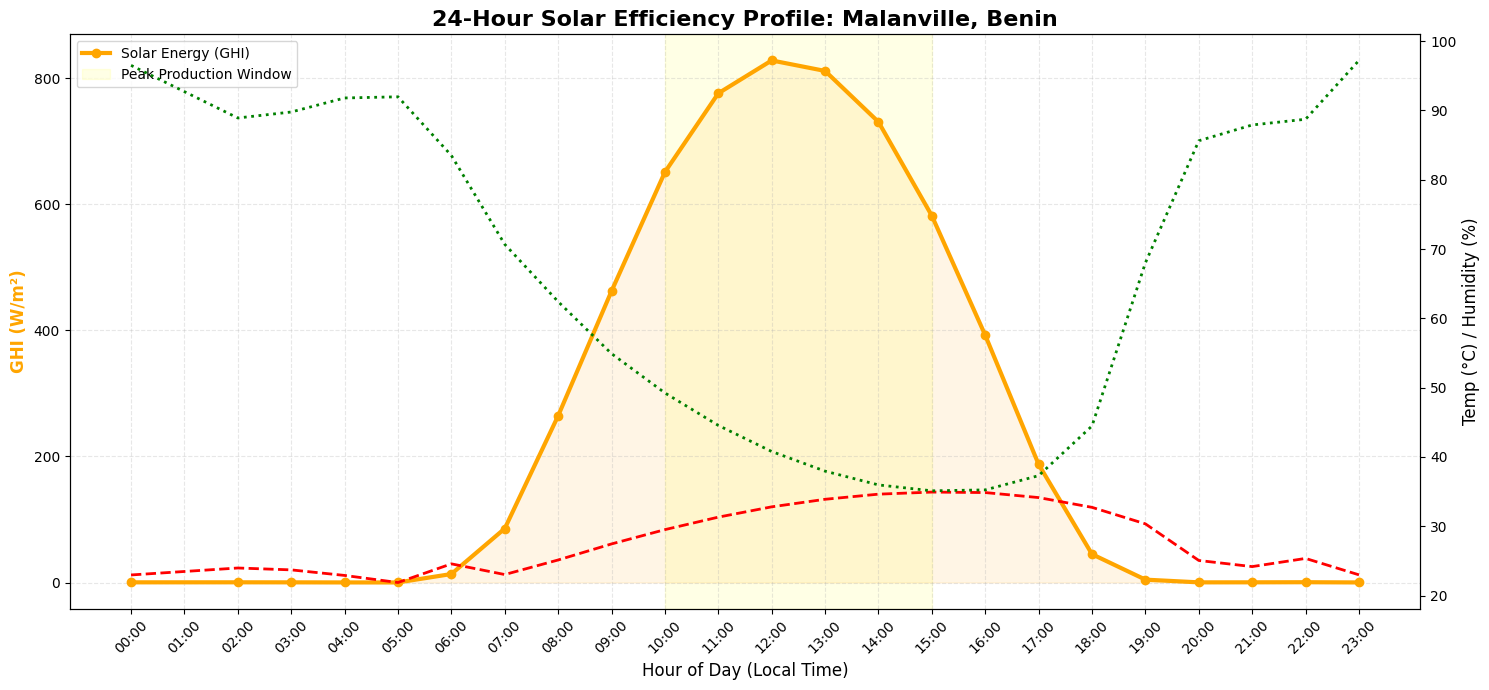

In [72]:
# --- STEP 1: FIX THE DATA ORDER ---
# We must include 'RH' in the selection here!
hourly_data = df_daytime.groupby('Hour')[['GHI', 'Tamb', 'RH']].mean()

# --- STEP 2: PLOT THE DATA ---
fig, ax1 = plt.subplots(figsize=(15, 7))

# 1. Primary Axis: GHI (Solar Energy)
ax1.fill_between(hourly_data.index, hourly_data['GHI'], color='orange', alpha=0.1)
ax1.plot(hourly_data.index, hourly_data['GHI'], color='orange', marker='o', linewidth=3, label='Solar Energy (GHI)')
ax1.set_ylabel('GHI (W/m²)', color='orange', fontsize=12, fontweight='bold')

# 2. Secondary Axis: Temp & Humidity (The Penalties)
ax2 = ax1.twinx()
ax2.plot(hourly_data.index, hourly_data['Tamb'], color='red', linestyle='--', linewidth=2, label='Ambient Temp (°C)')
ax2.plot(hourly_data.index, hourly_data['RH'], color='green', linestyle=':', linewidth=2, label='Humidity (%)')
ax2.set_ylabel('Temp (°C) / Humidity (%)', color='black', fontsize=12)

# --- THE FIX: SHOW ALL 24 HOURS ---
ax1.set_xticks(range(0, 24)) 
ax1.set_xticklabels([f"{h:02d}:00" for h in range(0, 24)], rotation=45)

# 3. Strategy Highlight: The Peak Production Window
ax1.axvspan(10, 15, color='yellow', alpha=0.1, label='Peak Production Window')

# Formatting
plt.title('24-Hour Solar Efficiency Profile: Malanville, Benin', fontsize=16, fontweight='bold')
ax1.set_xlabel('Hour of Day (Local Time)', fontsize=12)
ax1.grid(True, which='both', linestyle='--', alpha=0.3)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + labels2, labels1 + labels2, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()


## 24-Hour Efficiency Profile: The Solar "Heartbeat"
This chart visualizes the daily battle between the site's Fuel (GHI) and its primary Efficiency Killers (Temperature & Humidity). By mapping these together, we can identify the exact "Operational Window" for the Benin site.
1. The Peak Production Window (10:00 – 15:00)
Observation: The yellow-shaded region highlights the 5 hours of maximum energy harvest.
Business Insight: This is the "Golden Window." To maximize ROI, the panels must be at their cleanest before 10:00 AM to capture this peak irradiance without obstruction.
2. The Afternoon "Thermal Penalty"
Observation: Note that the Ambient Temperature (Red) continues to climb even after the Sun (GHI) begins its afternoon descent.
Business Insight: This "Thermal Lag" means the panels are at their hottest when the sun is still producing significant power. This results in a physical Efficiency Drop in the afternoon, suggesting that heat-tolerant modules are a high-value investment for this region.
3. The "Night-Mud" Risk (Morning Humidity)
Observation: Humidity (Green) is at its maximum (near 90-100%) during the early morning hours, exactly when the GHI curve begins to rise.
Business Insight: High morning humidity mixed with settled dust creates a "muddy" layer on the glass. Cleaning should be prioritized before 09:00 AM to ensure the panels are clear before the sun "bakes" this debris onto the surface.
4. Operational Reliability
Observation: The smooth rise and fall of the GHI "mountain" (Orange) suggests a reliable, consistent solar resource during the day, provided the environmental penalties of heat and dust are managed.


This section combines solar potential and environmental risks into a single investment score to support decision-making.

In [39]:
# =============================
# Investment Scoring System
# =============================

# Step 1: Use daytime data
data = df_daytime.copy()

# Step 2: Compute mean values
mean_ghi = data['GHI'].mean()
mean_rh = data['RH'].mean()
mean_wsgust = data['WSgust'].mean()
mean_precip = data['Precipitation'].mean()

print("Raw Metrics:")
print(f"GHI: {mean_ghi:.2f}")
print(f"RH: {mean_rh:.2f}")
print(f"WSgust: {mean_wsgust:.2f}")
print(f"Precipitation: {mean_precip:.4f}")

Raw Metrics:
GHI: 477.40
RH: 46.92
WSgust: 3.64
Precipitation: 0.0013


In [40]:
# Step 3: Normalize (min-max scaling)

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

norm_ghi = normalize(data['GHI']).mean()
norm_rh = normalize(data['RH']).mean()
norm_wsgust = normalize(data['WSgust']).mean()
norm_precip = normalize(data['Precipitation']).mean()

In [43]:
# Step 4: Assign weights
w_ghi = 0.5
w_rh = 0.2
w_wind = 0.2
w_precip = 0.1

# Step 5: Compute score
investment_score = (
    (w_ghi * norm_ghi)
    - (w_rh * norm_rh)
    - (w_wind * norm_wsgust)
    - (w_precip * norm_precip)
)

print(f"\nInvestment Score: {investment_score:.4f}")


Investment Score: 0.0447


## Conclusion

This notebook performed a comprehensive EDA on the Benin solar dataset. We loaded the data, cleaned it by handling missing values, and performed various analyses to uncover relationships between different variables. The cleaned dataset is now ready for more advanced modeling.

In [77]:
# Save cleaned dataset
df_clean.to_csv('../data/benin_clean.csv', index=False)